# 📦 Procurement Analytics: SARIMA Time-Series Forecasting
---

**Model:** SARIMA (Seasonal AutoRegressive Integrated Moving Average)  
**SDG:** SDG 12 – Responsible Consumption and Production  
**Dataset:** Enterprise Procurement Orders (2022–2023)
https://www.kaggle.com/datasets/shahriarkabir/procurement-kpi-analysis-dataset

---




# Phase 1 · Business Understanding
**Understand the procurement forecasting problem, define project objectives, and identify the business value of predictive analytics before performing technical analysis.**


### 1.1 Business Problem

> A procurement office manages hundreds of supplier transactions across multiple procurement categories every month. However, procurement personnel often struggle to accurately anticipate procurement spending fluctuations due to changing operational requirements, supplier pricing behavior, inflationary pressure, seasonal purchasing patters, and varying procurement demand.

> Without accurate forecasting, the office may experience poor budgeting decisions, delayed procurement planning, inefficient supplier coordination, reactive purchasing behavior, and operational disruptions caused by inaccurate spending estimates.

> As procurement operations expands, manually estimating future procurement costs becomes increasingly unreliable and inefficient.



### 1.2 Business Goal

> Forecast the future monthly procurement costs using Time Series Forecasting model, SARIMA, to support proactive procurement operational planning, improve budget allocation, supplier negotiation, and reduce financial uncertainty.

> The forecasting model predicts procurment costs for the next 6 months using historical procurement transaction data.


### 1.3 SDG Alignment

> The project aligns the forecasting analysis with sustainable development objectives. This analysis supports

>**SDG 12: Responsible Consumption and Production**

>by improving procurement efficiency, resource planning, operational sustainability, and financial decision-making.

### 1.4 Environment Setup
> Import all required Python libraries, forecasting tools, visualization packages, and statistical analysis modules.

> These libraries provides data processing capabilities, time-series forecasting functionality, statistical testing tools, forecasting evaluation metrics, and visualization support which are necessary for building and evaluating the SARIMA forecasting model.

In [46]:
# pmdarima provides auto_arima for automatic SARIMA order selection
!pip install pmdarima --quiet

print("Packages installed successfully")

Packages installed successfully


In [47]:
# -- To suppress unnecessary warning -----------
import warnings
warnings.filterwarnings('ignore')

# -- Core ---------------------------------------
import numpy as np
import pandas as pd

# -- Visualization ------------------------------
import matplotlib.pyplot as plt

# -- Time Series Analysis Tools -----------------
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

# -- Evaluation Metrics ------------------------
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# -- Diagnostic Tests --------------------------
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import acorr_ljungbox

# -- Auto Arima --------------------------------
from pmdarima import auto_arima

print("All libraries imported successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

All libraries imported successfully.
   pandas  : 2.2.2
   numpy   : 2.0.2


### 1.5 Configuration

In [48]:
# -- Random Seed ------------------------------
## This ensures reproducibility of results

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# -- Forecasting Setting ----------------------

FORECAST_HORIZON = 6                          # Number of months to forecast into the future
TEST_SIZE = 12                                # Number of observations reserved for testing
FREQ = 'MS'                                   # Monthly frequency start

# -- Visualization Color ----------------------

BLUE = {
    'navy':   '#001D39',
    'dark':   '#0A4174',
    'mid':    '#49769F',
    'teal':   '#4E8EA2',
    'slate':  '#6EA2B3',
    'sky':    '#7BBDE8',
    'ice':    '#BDD8E9',
    'bg':     '#EEF5FB',
    'white':  '#F5FAFF',
}

CLUSTER_COLORS = [
    '#001D39',
    '#0A4174',
    '#49769F',
    '#4E8EA2',
    '#7BBDE8'
]


# -- Global Matplotlib Settings

plt.rcParams.update({

    # Figure styling
    'figure.facecolor': BLUE['bg'],
    'figure.dpi': 110,

    # Axes styling
    'axes.facecolor': BLUE['white'],
    'axes.edgecolor': BLUE['slate'],
    'axes.labelcolor': BLUE['navy'],
    'axes.titlecolor': BLUE['navy'],
    'axes.grid': True,
    'axes.axisbelow': True,

    # Grid styling
    'grid.color': '#D6E8F5',
    'grid.linewidth': 0.6,

    # Tick styling
    'xtick.color': BLUE['mid'],
    'ytick.color': BLUE['mid'],

    # Font styling
    'font.family': 'DejaVu Sans'
})

# -- Clean Axis Functions

def clean_ax(ax, grid_axis='y'):

    # Remove unnecessary borders
    ax.spines[['top', 'right']].set_visible(False)

    # Light borders
    ax.spines['left'].set_color(BLUE['ice'])
    ax.spines['bottom'].set_color(BLUE['ice'])

    # Grid
    ax.grid(
        axis=grid_axis,
        color='#D6E8F5',
        linewidth=0.6
    )

    # Tick size
    ax.tick_params(labelsize=8.5)


# Phase 2 · Data Understanding
**Get familiar with the data structure, quality, and behavior**

---

### 2.1 Load Dataset
> Load the procurement data into the notebook

In [49]:
df = pd.read_csv('Procurement KPI Analysis Dataset.csv')

# Display dataset dimensions
print(f"Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# Display column names
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully.
Rows    : 777
Columns : 11

Columns:
['PO_ID', 'Supplier', 'Order_Date', 'Delivery_Date', 'Item_Category', 'Order_Status', 'Quantity', 'Unit_Price', 'Negotiated_Price', 'Defective_Units', 'Compliance']


> This confirms that the procurement dataset was imported successfully.

> - 777 rows represent procurement transactions or purchase orders.
> - 11 columns represent the variables or attributes recorded for each transaction.

>This output is important because it verifies that the dataset is complete and readable before analysis begins.

### 2.2 Data Inspection
**Understand the structure and quality of the dataset.**

This helps identify for missing values, incorrect data types, dataset dimensions, and overall data quality


In [50]:
# -- Display first 5 rows ----------------------
print("\nFIRST 5 ROWS")
df.head()


FIRST 5 ROWS


,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No


In [51]:
# -- Display last 5 rows ----------------------
print("\nLAST 5 ROWS")
df.tail()


LAST 5 ROWS


,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
772,PO-00773,Delta_Logistics,2023-02-11,2023-02-20,Electronics,Delivered,1685,43.42,42.24,262.0,Yes
773,PO-00774,Alpha_Inc,2022-07-23,NaN,Office Supplies,Delivered,445,68.94,60.35,7.0,Yes
774,PO-00775,Gamma_Co,2022-03-19,2022-04-07,Raw Materials,Delivered,494,94.82,81.89,29.0,Yes
775,PO-00776,Beta_Supplies,2023-08-30,2023-09-11,MRO,Delivered,1306,21.05,18.27,128.0,Yes
776,PO-00777,Beta_Supplies,2023-12-09,2023-12-11,Office Supplies,Delivered,1988,105.20,93.23,187.0,Yes


In [52]:
# -- Display dataset information ---------------
print("\nDATA INFO")
df.info()


DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             777 non-null    object 
 1   Supplier          777 non-null    object 
 2   Order_Date        777 non-null    object 
 3   Delivery_Date     690 non-null    object 
 4   Item_Category     777 non-null    object 
 5   Order_Status      777 non-null    object 
 6   Quantity          777 non-null    int64  
 7   Unit_Price        777 non-null    float64
 8   Negotiated_Price  777 non-null    float64
 9   Defective_Units   641 non-null    float64
 10  Compliance        777 non-null    object 
dtypes: float64(3), int64(1), object(7)
memory usage: 66.9+ KB


In [53]:
# -- Display dataset dimensions ----------------
print("\nDATA SHAPE")
print(df.shape)


DATA SHAPE
(777, 11)


In [54]:
# -- Check missing values ----------------------
print("\nMISSING VALUES")
print(df.isnull().sum())


MISSING VALUES
PO_ID                 0
Supplier              0
Order_Date            0
Delivery_Date        87
Item_Category         0
Order_Status          0
Quantity              0
Unit_Price            0
Negotiated_Price      0
Defective_Units     136
Compliance            0
dtype: int64


> As per the result, Delivery_Date and Defective_Units are missing due to Pending/Cancelled orders

### 2.3 Categorical Column Distribution
**Examine value distributions for categorical variables**

In [55]:
cat_cols = ['Supplier', 'Item_Category', 'Order_Status']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())
    print("-" * 35)


Supplier:
Supplier
Delta_Logistics    171
Epsilon_Group      166
Beta_Supplies      156
Gamma_Co           143
Alpha_Inc          141
-----------------------------------

Item_Category:
Item_Category
Office Supplies    174
MRO                164
Electronics        152
Packaging          148
Raw Materials      139
-----------------------------------

Order_Status:
Order_Status
Delivered              560
Pending                 81
Partially Delivered     73
Cancelled               63
-----------------------------------


> The output shows how procurement transactions are distributed among categories and purchase orders

# Phase 3 - Data Preparation

**Prepare the dataset for time-series forecasting**

> This includes converting dates, sorting chronologically, and creating monthly aggregation.




### 3.1 Convert Data and Column

> Converts purchase order date column into datetime format. Time-series forecasting models require properly formatted datetime values to recognize chronological order, identify trends and seasonality, perform time-based aggregation, and enable accurate forecasting operations.

In [56]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
print(df['Order_Date'].info())


<class 'pandas.core.series.Series'>
RangeIndex: 777 entries, 0 to 776
Series name: Order_Date
Non-Null Count  Dtype         
--------------  -----         
777 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 6.2 KB
None


### 3.2 Sort Data Chronologically
**Ensures records are ordered correctly by time**

In [57]:
df = df.sort_values('Order_Date')
df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
558,PO-00559,Alpha_Inc,2022-01-01,2022-01-07,Raw Materials,Delivered,1042,36.74,35.78,33.0,Yes
179,PO-00180,Alpha_Inc,2022-01-01,2022-01-12,Electronics,Delivered,552,21.52,18.79,13.0,Yes
521,PO-00522,Delta_Logistics,2022-01-02,2022-01-06,Packaging,Delivered,85,22.54,20.68,6.0,Yes
302,PO-00303,Alpha_Inc,2022-01-03,2022-01-20,Packaging,Delivered,172,63.61,55.92,4.0,Yes
420,PO-00421,Alpha_Inc,2022-01-04,2022-01-06,Electronics,Delivered,1004,50.70,46.59,27.0,Yes


### 3.3 Feature Engineering
**We performed feature engineering by creating a Total Cost feature from Negotiated Price × Quantity.**

In [58]:
df['Total_Cost'] = df['Negotiated_Price'] * df['Quantity']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 777 entries, 558 to 649
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   PO_ID             777 non-null    object        
 1   Supplier          777 non-null    object        
 2   Order_Date        777 non-null    datetime64[ns]
 3   Delivery_Date     690 non-null    object        
 4   Item_Category     777 non-null    object        
 5   Order_Status      777 non-null    object        
 6   Quantity          777 non-null    int64         
 7   Unit_Price        777 non-null    float64       
 8   Negotiated_Price  777 non-null    float64       
 9   Defective_Units   641 non-null    float64       
 10  Compliance        777 non-null    object        
 11  Total_Cost        777 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(6)
memory usage: 95.1+ KB


### 3.4 Create Monthly Cost Time Series

> Aggregate procurement transactions into monthly procurement cost totals. SARIMA forecasting performs better on continuous numerical time-series data rather than raw transactional records.

> Monthly aggregation creates a structure time series, reduces transactional noise, highlights spending trends, improves seasonal pattern detection, and produces more stable forecasting behavior.

In [59]:
monthly_cost = (
    # -- Group records by month
    df.groupby(pd.Grouper(key='Order_Date', freq=FREQ))['Total_Cost']

    # -- Sum total monthly procurement cost
    .sum()
)

# -- Convert to DataFrame

original_df = monthly_cost.reset_index()
original_df.columns = ['Order_Date', 'Total_Cost']

original_df_clean = original_df[:-2].copy()

print("\nREAL DATA (last 5 rows after trimming)")
print(original_df_clean.tail())


REAL DATA (last 5 rows after trimming)
   Order_Date  Total_Cost
18 2023-07-01  2365673.85
19 2023-08-01  2010221.33
20 2023-09-01  2230645.28
21 2023-10-01  1869843.20
22 2023-11-01  2583675.29


### 3.5 Synthetic Historical Extension

> Generate synthetic historical procurement records prior to the original dataset period. The original dataset contains only approximately 2 years of monthly observations, which is relatively limited for SARIMA forecasting.

> Synthetic historical extension helps increase the number of observations, improve trend learning, stabilize seasonal estimation, improve forecasting consistency, and reduce instability caused by small datasets. The synthetic values simulate realistic procurement growth operational volatility, seasonal fluctuations, and financial variability.

> This extension is created strictly for educational forecasting purposes. In a real live data, no extension must be done.

In [60]:
synthetic_dates = pd.date_range(
    start='2019-01-01',
    end='2021-12-01',
    freq='MS'
)

n_synthetic = len(synthetic_dates)   # 36 months

real_start     = original_df_clean['Total_Cost'].iloc[0]
real_end       = original_df_clean['Total_Cost'].iloc[-1]
n_real         = len(original_df_clean)
monthly_growth = (real_end / real_start) ** (1 / (n_real - 1)) - 1

# -- Back-calculate base cost so synthetic series ends near real data start:
base_cost = real_start / ((1 + monthly_growth) ** n_synthetic)

print(f"\nSYNTHETIC DATA PARAMETERS")
print(f"Real start value    : ₱{real_start:,.2f}")
print(f"Real end value      : ₱{real_end:,.2f}")
print(f"Monthly growth rate : {monthly_growth:.4f} ({monthly_growth*100:.2f}%)")
print(f"Synthetic base cost : ₱{base_cost:,.2f}")


# -- Generate Synthetic Cost Values
rng             = np.random.default_rng(RANDOM_SEED)
synthetic_costs = []
current_cost    = base_cost

for i, date in enumerate(synthetic_dates):

    current_cost    *= (1 + monthly_growth)

    # Seasonal swing: 10% of current cost (proportional to scale)
    seasonal_effect  = current_cost * 0.10 * np.sin(2 * np.pi * i / 12)

    # Random noise: 8% std dev of current cost (proportional to scale)
    noise            = rng.normal(0, current_cost * 0.08)

    synthetic_value  = current_cost + seasonal_effect + noise

    # Prevent negative values
    synthetic_value  = max(synthetic_value, 10_000)

    synthetic_costs.append(synthetic_value)

# -- Create Synthetic DataFrame
synthetic_df = pd.DataFrame({
    'Order_Date': synthetic_dates,
    'Total_Cost': synthetic_costs
})

# -- Sanity check: synthetic end vs real start should be close
print(f"\nSANITY CHECK (should be within ~20% of each other)")
print(f"Synthetic last value : ₱{synthetic_df['Total_Cost'].iloc[-1]:,.2f}")
print(f"Real data first value: ₱{real_start:,.2f}")

print("\nSYNTHETIC DATA SAMPLE")
print(synthetic_df.head())




SYNTHETIC DATA PARAMETERS
Real start value    : ₱1,536,378.93
Real end value      : ₱2,583,675.29
Monthly growth rate : 0.0239 (2.39%)
Synthetic base cost : ₱656,305.87

SANITY CHECK (should be within ~20% of each other)
Synthetic last value : ₱1,598,322.32
Real data first value: ₱1,536,378.93

SYNTHETIC DATA SAMPLE
  Order_Date     Total_Cost
0 2019-01-01  688378.269638
1 2019-02-01  665219.974776
2 2019-03-01  807821.727986
3 2019-04-01  847770.552305
4 2019-05-01  687284.142343


**Interpretation**

The synthetic generation process was calibrated using real procurement growth behavior,
historical procurement trends,
seasonal variability, and
random operational fluctuations.

The estimated monthly procurent growth rate of:
> 2.39%

indicates a gradual increase in procurement spending over time, potentially reflecting operational expansion and inflationary effects.

The sanity check demonstrated that the final synthetic procurement value closely aligned with the first real procurement value, indicating smooth continuity between synthetic and original procurement records.

Overall, the synthetic extension successfully increased the time-series horizon while preserving realistic procurement cost behavior for forecasting purposes.

*****

In [61]:
# -- Combine Synthetic and Original
combined_df = pd.concat([
    synthetic_df, original_df_clean
])

# -- Sort chronologically
combined_df = combined_df.sort_values(
    'Order_Date'
)

# -- Create Final Time Series
ts_full = combined_df.set_index('Order_Date')['Total_Cost']
ts_full.head()

,Total_Cost
Order_Date,
2019-01-01,688378.269638
2019-02-01,665219.974776
2019-03-01,807821.727986
2019-04-01,847770.552305
2019-05-01,687284.142343


### 3.6 Ensure Monthly Frequency
**Forces monthly intervals in the index**

In [62]:
ts_full = ts_full.asfreq(FREQ)

### 3.7 Handle Missing Months
**If a month has no procurement records, assume financial activity was zero.**

In [63]:
ts_full = ts_full.fillna(0)

# Display processed series
print("\nTIME SERIES")
print(ts_full.head())

# Show date range
print("\nDATE RANGE")
print(ts_full.index.min(), "to", ts_full.index.max())


TIME SERIES
Order_Date
2019-01-01    688378.269638
2019-02-01    665219.974776
2019-03-01    807821.727986
2019-04-01    847770.552305
2019-05-01    687284.142343
Freq: MS, Name: Total_Cost, dtype: float64

DATE RANGE
2019-01-01 00:00:00 to 2023-11-01 00:00:00


### 3.8 Log Transformation

> Apply logarithmic transformation to procurement cost values using **np.log1p()**

> Procurement financial data is often highly skewed, volatile, and affected by extreme spending spikes. Log transformation helps stabilize variance, reduce extreme fluctuations, improve model learning, create smoother forecasting patterns, and improve SARIMA forecasting performance.

In [64]:
ts_full = np.log1p(ts_full)
ts_full.head()

,Total_Cost
Order_Date,
2019-01-01,13.442095
2019-02-01,13.407875
2019-03-01,13.602098
2019-04-01,13.650366
2019-05-01,13.440505


### 3.9 Exploratory Data Analysis
**Visualize procurement cost behavior over time.**

This helps identify trends, fluctuations, spikes, and possible seasonality.

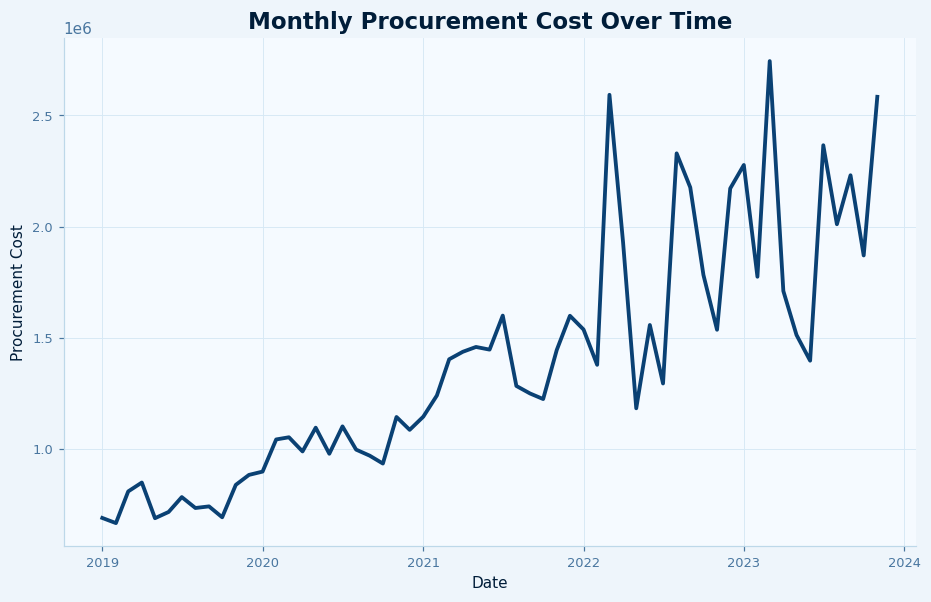

In [65]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(
    ts_full.index,
    np.expm1(ts_full),
    color=BLUE['dark'],
    linewidth=2.5
)

ax.set_title(
    'Monthly Procurement Cost Over Time',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel('Date')

ax.set_ylabel('Procurement Cost')

clean_ax(ax)

plt.show()

> The figure shows a clear upward trend in monthly procurement costs from 2019 to 2023, indicating that procurement spending generally increased over time. During the earlier years, the procurement costs appear more stable and gradually increasing. However, beginning around 2021 to 2022, the series becomes more volatile, with larger fluctuations and several sharp spikes in spending.

> These spikes suggest periods of unusually high procurement activity, which may be caused by increased purchasing demand, inflationary effects, supplier price changes, or operational expansion. Despite the volatility, the overall movement of the series continues upward, showing that procurement expenditures consistently grew throughout the observed period.

> The presence of both trend and fluctuation indicates that the data contains meaningful temporal patterns rather than random behavior, making it suitable for time-series forecasting analysis.

### 3.10 Seasonal Decomposition
**Break the series into trend, seasonality, and residuals**

Dataset is small, so decomposition is exploratory only.

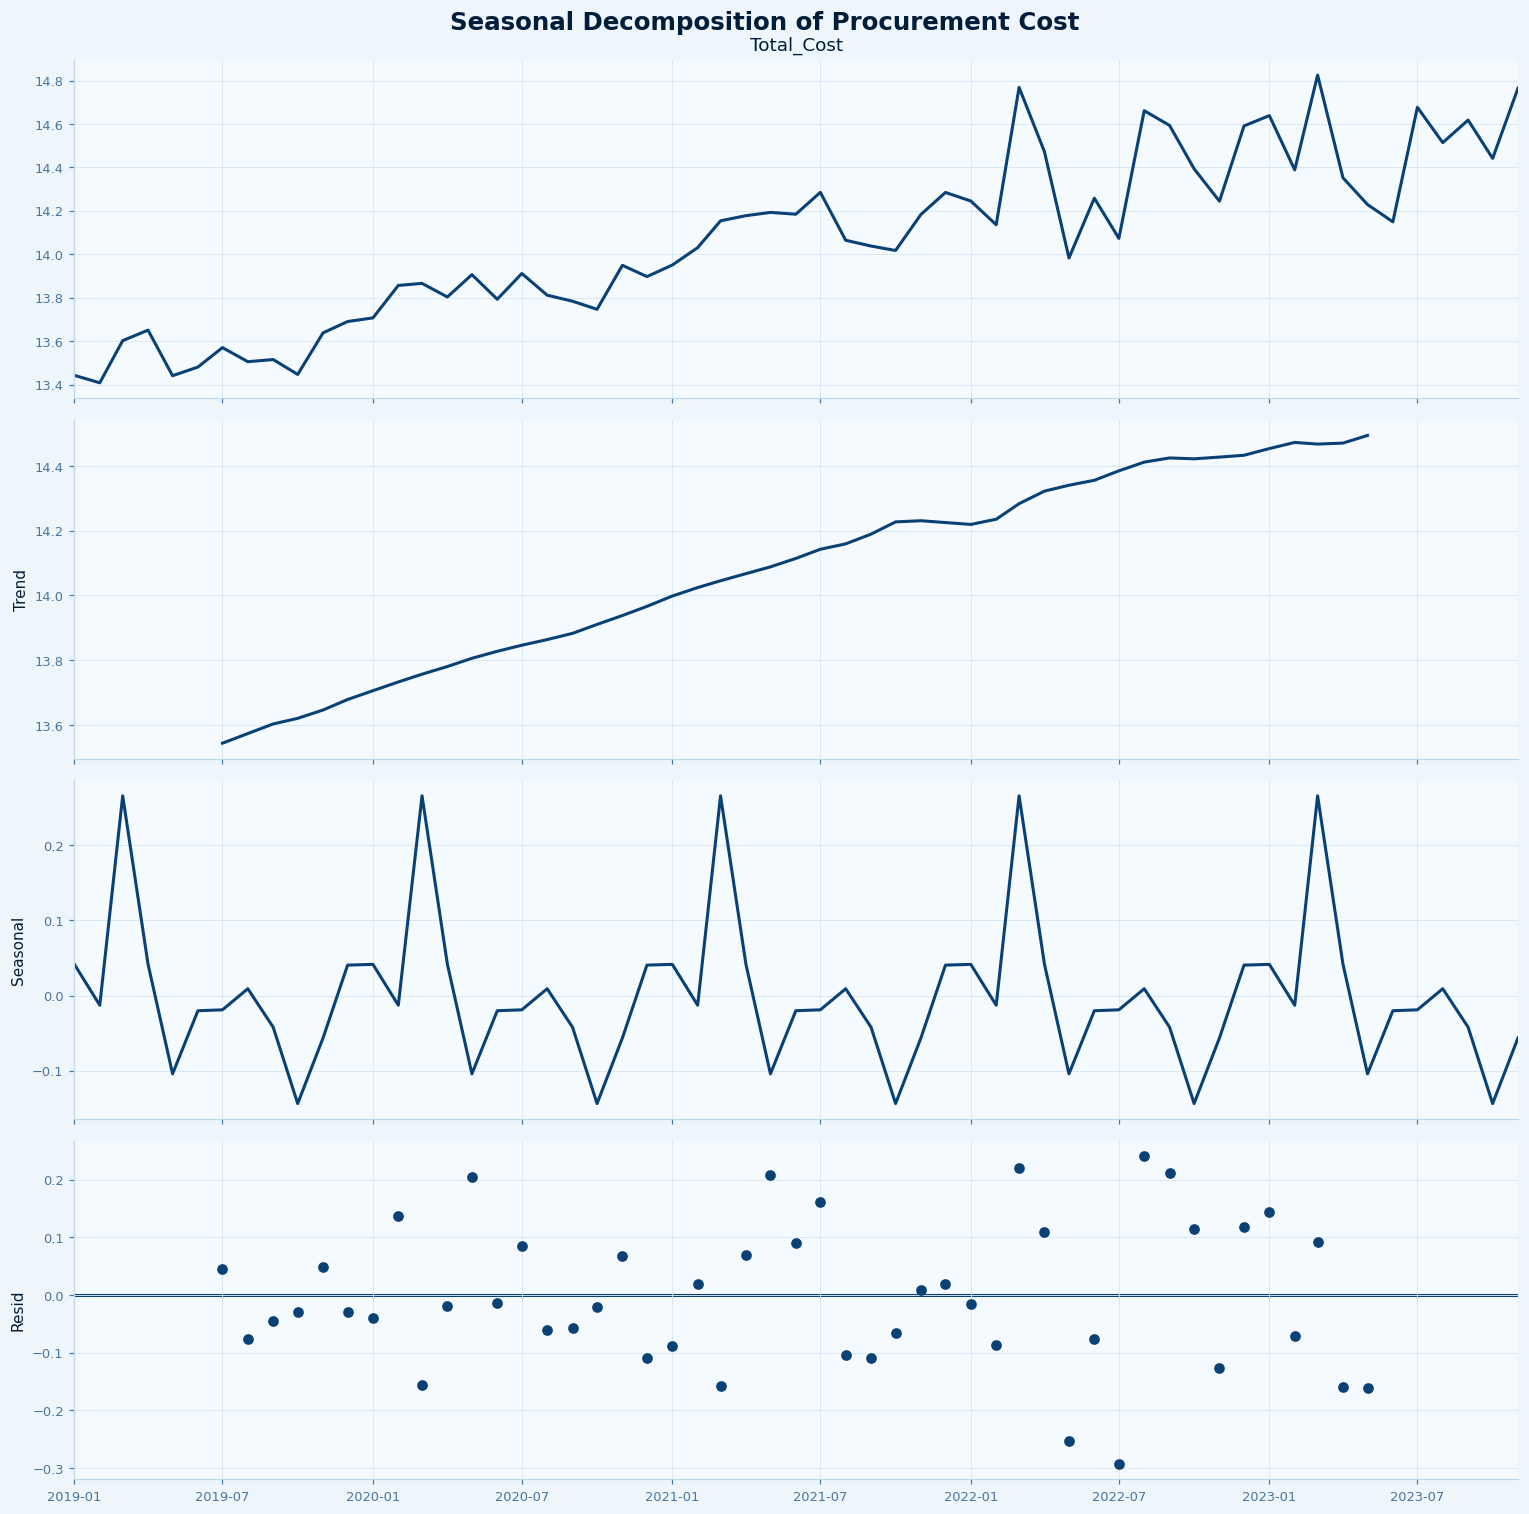

In [66]:
decomposition = seasonal_decompose(
    ts_full,
    model='additive',
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(14, 14)

for ax in fig.axes:

    clean_ax(ax, grid_axis='y')

    for line in ax.lines:
        line.set_color(BLUE['dark'])
        line.set_linewidth(2)

fig.suptitle(
    'Seasonal Decomposition of Procurement Cost',
    fontsize=16,
    fontweight='bold',
    color=BLUE['navy']
)

plt.tight_layout()

plt.show()

> The seasonal decomposition plot shows that procurement costs increased over time, as seen in the upward trend line. The seasonal part shows repeating spending patterns that happen regularly during certain periods.

> The residual part shows small random changes that were not explained by the trend or seasonal patterns. Most residual values are close to zero, which means the model was able to capture most of the important procurement spending behavior.

### 3.11 Train - Test Split
**Split the data into training set and testing set**

The model learns from training data and is evaluated on unseen testing data.

In [67]:
train = ts_full[:-TEST_SIZE]
test = ts_full[-TEST_SIZE:]

# -- Display sizes
print(f"Train Size: {len(train)}")
print(f"Test Size: {len(test)}")

Train Size: 47
Test Size: 12


### 3.12 Stationarity Test

> Perform the Augmented Dickey-Fuller (ADF) test to determine whether the time series is stationary.

> SARIMA forecasting requires stationary data because stationary series have stable mean, stable variance, and consistent temporal behavior. Non-stationary data may produce unstable forecasts, unreliable trends, and inaccurate model parameters.

> The ADF test helps determine whether differencing is required before modeling.

In [68]:
def adf_test(series):

    # -- Run Augmented Dickey-Fuller test
    result = adfuller(series)

    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')

    # -- Interpretation
    if result[1] <= 0.05:
        print("Series is stationary")
    else:
        print("Series is NOT stationary")

# -- Run ADF test
adf_test(train)

ADF Statistic: -0.7740
p-value: 0.8266
Series is NOT stationary


> The ADF test shows that the procurement cost series was not stationary because the p-value was greater than 0.05. This means the data still had trends or changing patterns over time.

### 3.13 Differencing
**Apply differencing to remove trend and make the series stationary**

In [69]:
train_diff = train.diff().dropna()

print("\nADF TEST AFTER DIFFERENCING")

# -- Recheck stationarity
adf_test(train_diff)


ADF TEST AFTER DIFFERENCING
ADF Statistic: -4.2989
p-value: 0.0004
Series is stationary


> After applying differencing, the ADF test produced a very small p-value, indicating that the series became stationary. This means the trend was successfully removed, making the data suitable for SARIMA forecasting.

### 3.14 ACF and PACF Plots
**Help identify appropriate ARIMA parameters**

> **ACF** is used for identifying Moving Average (MA) terms

> **PACF** is used for identifying AutoRegressive (AR) terms

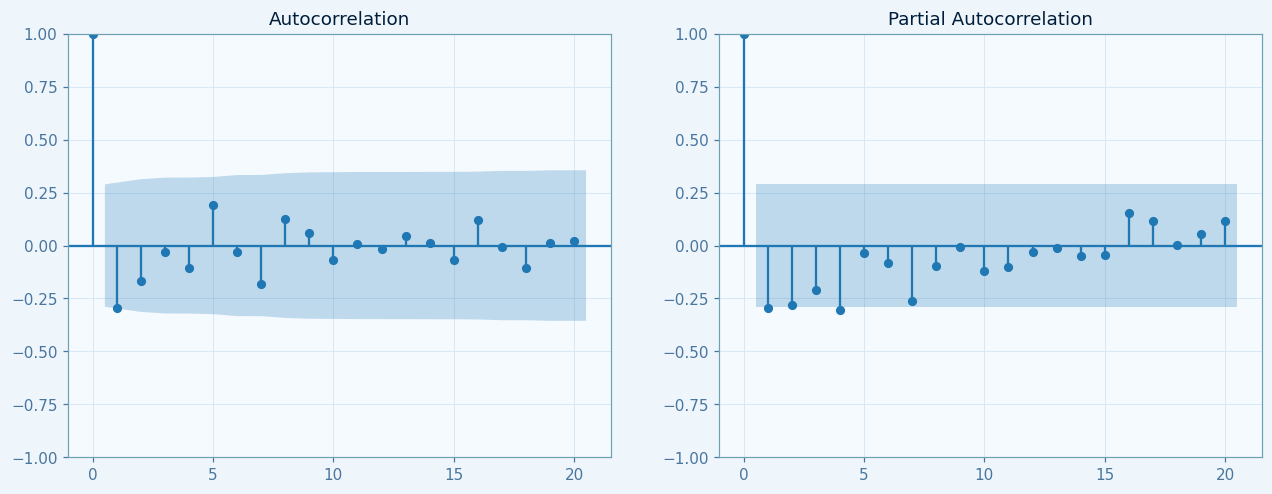

In [70]:
# Safe lag selection
lags_value = max(1, min(20, len(train_diff)//2 - 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot autocorrelation
plot_acf(train_diff, lags=lags_value, ax=axes[0])
axes[0].set_title('Autocorrelation')

# Plot partial autocorrelation
plot_pacf(train_diff, lags=lags_value, ax=axes[1])
axes[1].set_title('Partial Autocorrelation')

plt.show()

> The ACF and PACF plots show that most correlation values stay within the shaded confidence range, which suggests that the procurement cost data does not have very strong remaining patterns after preprocessing. A few spikes are visible at some lag values, indicating that there are still small relationships between previous and current procurement costs, which helped guide the SARIMA model selection.

# Phase 4 - Modeling

Identify optimal SARIMA orders using **auto_arima**, fit the model on training data, and generate forecasts.

### SARIMA Notation: SARIMA(p, d, q)(P, D, Q)m
| Parameter | Meaning |
|-----------|--------|
| p | Non-seasonal AR order - how many past values predict current |
| d | Non-seasonal differencing - how many times to difference for stationarity |
| q | Non-seasonal MA order - how many past forecast errors to include |
| P | Seasonal AR order |
| D | Seasonal differencing |
| Q | Seasonal MA order |
| m | Seasonal period (12 for monthly data with annual seasonality) |


### 4.1 Auto ARIMA Model Selection
 > Automatically identify the most appropriate SARIMA parameters using **auto_arima()**.

 > Selecting SARIMA parameters manually can be difficult and time-consuming. Auto ARIMA evaluates multiple parameter combinations and selects the model with the best statistical performance based onn AIC values, forecasting behavior, and model stability. It improves modeling efficiency, parameter optimization, and forecasting reliability.

In [71]:
auto_model = auto_arima(
    train,
    seasonal = True,
    m = 12,
    trace = True,
    suppress_warnings = True,
    stepwise = True
)

# -- Display selected model
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-29.557, Time=1.89 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-18.936, Time=0.09 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-19.151, Time=0.74 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=2.92 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-20.544, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=-31.658, Time=4.72 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=-34.583, Time=0.98 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=inf, Time=2.96 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=inf, Time=1.35 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=1.66 sec
 ARIMA(3,1,2)(0,0,0)[12] intercept   : AIC=inf, Time=3.56 sec
 ARIMA(2,1,3)(0,0,0)[12] intercept   : AIC=inf, Time=4.27 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=1.22 sec
 ARIMA(1,1,3)(0,0,0)[12] intercept   : AIC=-32.429, Time=0.91 sec
 ARIMA(3,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=1.44 sec

### 4.2 Build SARIMA
**Train the forecasting model using selected parameters**

In [72]:
model = SARIMAX(

    train,

    # -- ARIMA order from auto_arima
    order = auto_model.order,

    # -- Best seasonal order
    seasonal_order = auto_model.seasonal_order,

    # -- Add intercept
    trend = 'c',

    # Relax restrictions
    enforce_stationarity = False,
    enforce_invertibility = False
)

# -- Train model
model_fit = model.fit()

# -- Display model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Total_Cost   No. Observations:                   47
Model:               SARIMAX(2, 1, 2)   Log Likelihood                  20.492
Date:                Fri, 15 May 2026   AIC                            -28.985
Time:                        12:45:36   BIC                            -18.417
Sample:                    01-01-2019   HQIC                           -25.088
                         - 11-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0097      0.008      1.255      0.209      -0.005       0.025
ar.L1          0.9257      0.336      2.754      0.006       0.267       1.584
ar.L2         -0.3515      0.325     -1.081      0.2

### 4.2 Residual Analysis

> Evaluate the forecasting residuals after model training.

> A good SARIMA model should produce residuals that behave like random noise. Residual analysys helps verify whether important patterns were captures, autocorrelation remains, forecasting assumptioons are satisfied, and model behavior is statistically reasonable.

In [73]:
# -- Extract residuals
residuals = model_fit.resid

print(residuals)

Order_Date
2019-01-01    13.442095
2019-02-01    -6.265692
2019-03-01     1.865049
2019-04-01    -0.153280
2019-05-01    -0.297956
2019-06-01    -0.029981
2019-07-01     0.021526
2019-08-01    -0.103087
2019-09-01    -0.064342
2019-10-01    -0.151667
2019-11-01     0.052240
2019-12-01     0.015073
2020-01-01     0.017238
2020-02-01     0.160973
2020-03-01     0.122626
2020-04-01     0.065785
2020-05-01     0.178636
2020-06-01     0.017774
2020-07-01     0.149527
2020-08-01    -0.013445
2020-09-01    -0.039087
2020-10-01    -0.114509
2020-11-01     0.046422
2020-12-01    -0.092229
2021-01-01    -0.036342
2021-02-01     0.010456
2021-03-01     0.105436
2021-04-01     0.107290
2021-05-01     0.134897
2021-06-01     0.132322
2021-07-01     0.233361
2021-08-01    -0.013682
2021-09-01    -0.008627
2021-10-01    -0.087369
2021-11-01     0.015339
2021-12-01     0.028882
2022-01-01    -0.044861
2022-02-01    -0.151186
2022-03-01     0.472951
2022-04-01     0.049487
2022-05-01    -0.299200
2022-

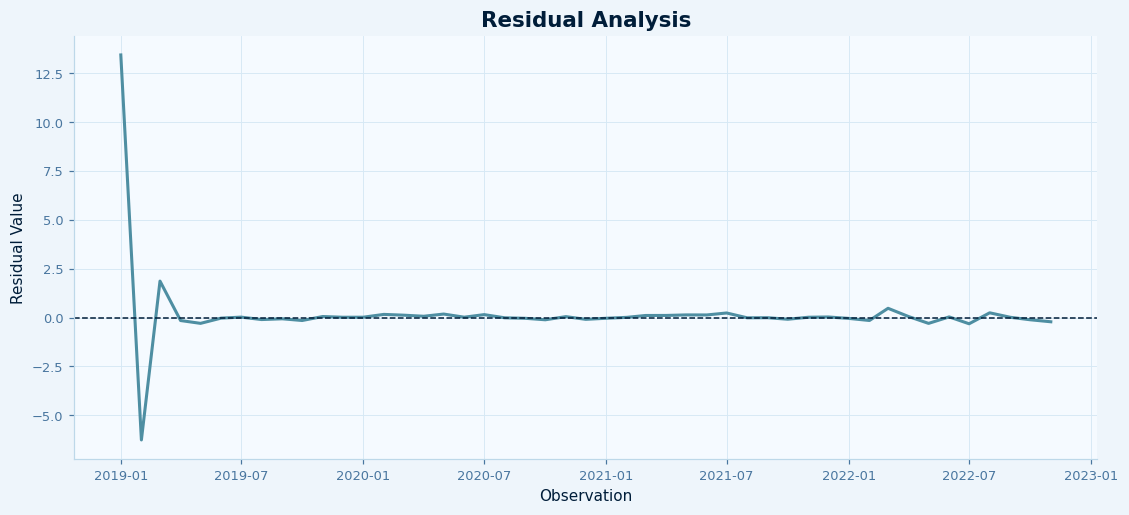

In [74]:
# --  Residual Visualization

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    residuals,
    color=BLUE['teal'],
    linewidth=2
)

ax.axhline(
    0,
    linestyle='--',
    color=BLUE['navy'],
    linewidth=1
)

ax.set_title(
    'Residual Analysis',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Observation')
ax.set_ylabel('Residual Value')
clean_ax(ax)
plt.show()

> The residual analysis shows that most residual values are close to zero, indicating that the SARIMA model was able to capture the overall procurement spending patterns reasonably well. However, there are a few large spikes at the beginning of the timeline, suggesting that the model had larger forecasting errors during some early observations.

> Overall, the residuals appear randomly distributed around zero, which suggests that the forecasting model performs reasonably well and does not show strong systematic prediction errors.

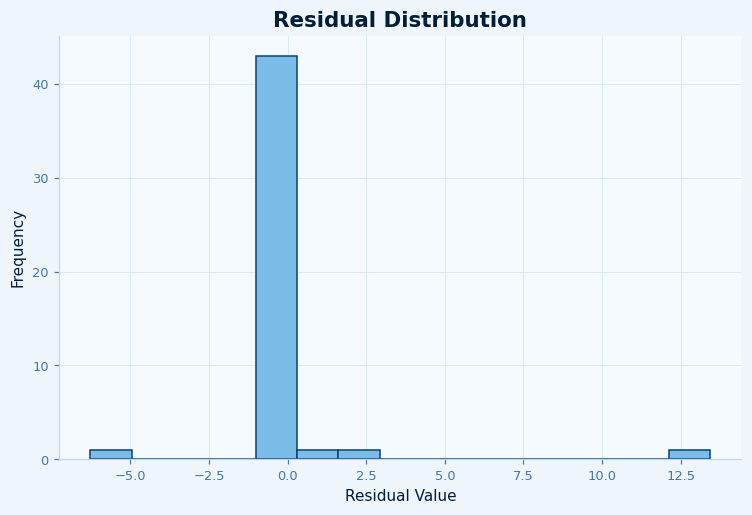

In [75]:
# -- Residual Histogram

# ============================================================
# RESIDUAL DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(8,5))

ax.hist(
    residuals,
    bins=15,
    color=BLUE['sky'],
    edgecolor=BLUE['dark']
)

ax.set_title(
    'Residual Distribution',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Residual Value')
ax.set_ylabel('Frequency')
clean_ax(ax)

plt.show()

> The residual distribution shows that most errors are close to zero, which means the SARIMA model predicted procurement costs fairly well most of the time. However, there are a few large errors, showing that the model had difficulty predicting some sudden changes or unusual spikes in procurement spending.

### 4.3 Shapiro-Wilk Test
**Check if residuals are approximately normally distributed**

In [76]:
# -- Remove missing values
clean_resid = residuals.dropna()

# -- Perform test
stat, p = shapiro(clean_resid)


print('\nSHAPIRO-WILK TEST')
print(f"Statistic : {stat:.4f}")
print(f"p-value   : {p}")


# -- Interpretation
if p > 0.05:
    print('Residuals approximately normal')
else:
    print('Residuals not normally distributed')



SHAPIRO-WILK TEST
Statistic : 0.3125
p-value   : 1.6322311400380758e-13
Residuals not normally distributed


> The Shapiro-Wilk test p-value is very small, indicating that the residuals are not normally distributed. This suggests that some irregular fluctuations or extreme procurement cost variations are still present in the forecasting errors.

### 4.4 Ljung-Box Test
**Check if residuals are independent. Good models produce residuals that resemble white noise.**

In [77]:
ljung = acorr_ljungbox(
    clean_resid,
    lags = [6],
    return_df = True
)

print('\nLJUNGB-BOX TEST')
print(ljung)


LJUNGB-BOX TEST
    lb_stat  lb_pvalue
6  9.854078   0.130933


> The Ljung-Box test p-value is greater than 0.05, which indicates that there is no significant autocorrelation remaining in the residuals. This means the SARIMA model was able to capture most of the important patterns in the procurement cost data.

### 4.5 Forecast on Test Data
**Generate forecasts for the testing period.**

In [78]:
forecast = model_fit.get_forecast(steps=TEST_SIZE)

# -- Extract predicted values
forecast_mean = forecast.predicted_mean
print(forecast_mean)

# -- Extract confidence intervals
forecast_ci = forecast.conf_int()
print(forecast_ci)

2022-12-01    14.485794
2023-01-01    14.593411
2023-02-01    14.617836
2023-03-01    14.612344
2023-04-01    14.608400
2023-05-01    14.616406
2023-06-01    14.634928
2023-07-01    14.658986
2023-08-01    14.684472
2023-09-01    14.709333
2023-10-01    14.733115
2023-11-01    14.756117
Freq: MS, Name: predicted_mean, dtype: float64
            lower Total_Cost  upper Total_Cost
2022-12-01         14.209135         14.762453
2023-01-01         14.315297         14.871524
2023-02-01         14.331476         14.904196
2023-03-01         14.316944         14.907745
2023-04-01         14.310055         14.906745
2023-05-01         14.317828         14.914983
2023-06-01         14.336321         14.933535
2023-07-01         14.360225         14.957747
2023-08-01         14.385596         14.983348
2023-09-01         14.410415         15.008252
2023-10-01         14.434189         15.032041
2023-11-01         14.457195         15.055038


### 4.6 Reverse Log Transformation
**Convert logarithmic forecasts back into actual procurement cost values.**

In [79]:
forecast_mean = np.expm1(forecast_mean)

forecast_ci = np.expm1(forecast_ci)

# -- Convert actual values back
actual = np.expm1(test)

print("\nFORECAST VALUES")
print(forecast_mean)

print("\nCONFIDENCE INTERVALS")
print(forecast_ci)


FORECAST VALUES
2022-12-01    1.954790e+06
2023-01-01    2.176895e+06
2023-02-01    2.230722e+06
2023-03-01    2.218505e+06
2023-04-01    2.209772e+06
2023-05-01    2.227533e+06
2023-06-01    2.269176e+06
2023-07-01    2.324431e+06
2023-08-01    2.384432e+06
2023-09-01    2.444456e+06
2023-10-01    2.503285e+06
2023-11-01    2.561532e+06
Freq: MS, Name: predicted_mean, dtype: float64

CONFIDENCE INTERVALS
            lower Total_Cost  upper Total_Cost
2022-12-01      1.482343e+06      2.577814e+06
2023-01-01      1.648369e+06      2.874886e+06
2023-02-01      1.675255e+06      2.970365e+06
2023-03-01      1.651085e+06      2.980925e+06
2023-04-01      1.639751e+06      2.977948e+06
2023-05-01      1.652546e+06      3.002580e+06
2023-06-01      1.683391e+06      3.058803e+06
2023-07-01      1.724115e+06      3.133768e+06
2023-08-01      1.768417e+06      3.215031e+06
2023-09-01      1.812856e+06      3.296105e+06
2023-10-01      1.856473e+06      3.375454e+06
2023-11-01      1.899677e+

# Phase 5 - Evaluation

> Evaluate forecasting accuracy using multiple statistical metrics.

> Forecasctng evaluation measures how closely predicted procurement costs match actual procurement costs.

> Multiple metrics are used because each metric evaluates forecasting performance differently:

1. MAE measures average error magnitude
2. RMSE penalizes large forecasting errors
3. MAPE measures percentage forecasting accuracy
4. SMAPE provides balanced percentage error evaluation
5. Forecast Bias measures systematic overforecasting or underforecasting


In [80]:
# -- Convert to arrays
actual_values = actual.values
predicted = forecast_mean.values

# -- Prevent division-by-zero
actual_safe = np.where(actual == 0, 1e-6, actual)

### 5.1 Metrics Calcuation

In [81]:
# Prevent division-by-zero
actual_safe = np.where(
    actual_values == 0,
    1e-6,
    actual_values
)

# -- Mean Absolute Error
mae = mean_absolute_error(actual_values, predicted)

# -- Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(actual_values, predicted))

# -- Mean Absolute Percentage Error
mape = mean_absolute_percentage_error(actual_safe, predicted) * 100

# -- Symmetric Mean Absolute Percentage Error
smape = np.mean(
    2 * np.abs(actual_values - predicted) / (np.abs(actual_values) + np.abs(predicted))
) * 100

# -- Forecast Bias
forecast_bias = np.mean(predicted - actual_values)

In [82]:
# -- Display Results

print("\nMODEL EVALUATION")

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"SMAPE: {smape:.2f}%")
print(f"Forecast Bias: {forecast_bias:.2f}")


MODEL EVALUATION
MAE: 389382.18
RMSE: 470432.10
MAPE: 21.92%
SMAPE: 19.01%
Forecast Bias: 238451.47


> The model evaluation results show that the SARIMA model achieved reasonably good forecasting performance.

> The MAE and RMSE values indicate the average forecasting error between predicted and actual procurement costs.

> The MAPE of 21.92% suggests that the forecasts were generally close to the actual values with moderate prediction error.

> The SMAPE value of 19.01% further shows that the model was able to capture the overall procurement spending trend reasonably well.

> The positive forecast bias indicates that the model slightly overestimated future procurement costs on average.

> Overall, the evaluation results suggest that the forecasting model is effective for analyzing procurement spending trends and supporting budgeting and financial planning decisions.

### 5.2 Visualize Test Forecast

**Compare historical data, actual values, and forecasted values.**

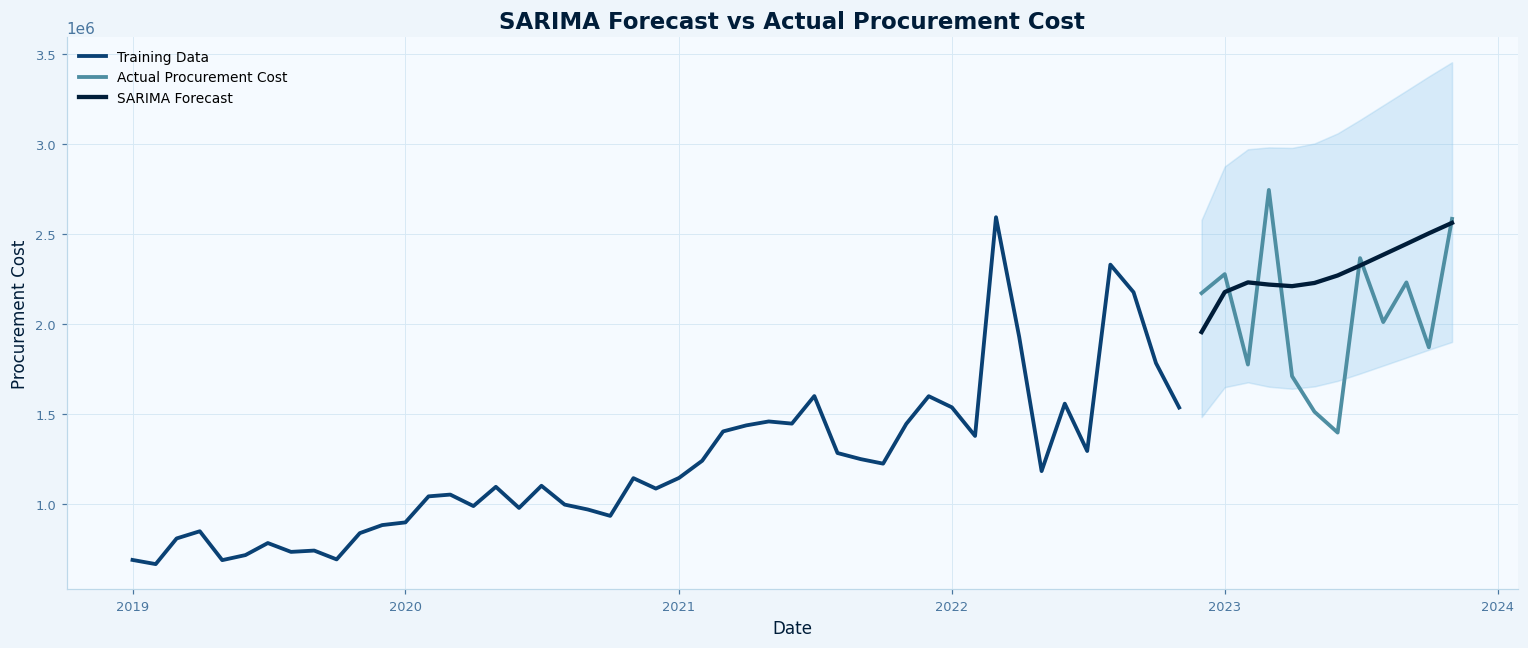

In [83]:
fig, ax = plt.subplots(figsize=(14,6))

# -- Plot training data
ax.plot(
    train.index,
    np.expm1(train),
    label='Training Data',
    color=BLUE['dark'],
    linewidth=2.5
)

# -- Plot actual values
ax.plot(
    test.index,
    np.expm1(test),
    label='Actual Procurement Cost',
    color=BLUE['teal'],
    linewidth=2.5
)

# -- Plot forecast values
ax.plot(
    test.index,
    forecast_mean,
    label='SARIMA Forecast',
    color=BLUE['navy'],
    linewidth=2.8
)

# -- Plot confidence intervals
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color=BLUE['sky'],
    alpha=0.25
)

ax.set_title(
    'SARIMA Forecast vs Actual Procurement Cost',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel(
    'Date',
    fontsize=11
)

ax.set_ylabel(
    'Procurement Cost',
    fontsize=11
)

ax.legend(
    frameon=False,
    fontsize=9
)

clean_ax(ax)
plt.tight_layout()
plt.show()

> The figure compares the SARIMA forecast with the actual procurement costs. The historical training data shows an overall upward trend with several fluctuations in procurement spending over time.

> The forecasted values generally follow the direction of the actual procurement costs, showing that the SARIMA model was able to capture the overall spending trend. The shaded area represents the confidence interval, which shows the possible range of future procurement costs.

> Overall, the results suggest that the model can reasonably predict procurement spending patterns and support future budgeting and procurement planning.

# Phase 6 - Deployment

**Refit the model on the full dataset (train + test) and generate the actionable business forecast. This is the output the procurement office will use.**

### 6.1 Final Model using Full Data

**Retrain the model using complete dataset before future forecasting.**

In [84]:
final_model = SARIMAX(
    ts_full,
    order = auto_model.order,
    seasonal_order = auto_model.seasonal_order,
    trend = 'c',
    enforce_stationarity = False,
    enforce_invertibility = False
)

# -- Fit final model
final_model_fit = final_model.fit()

### 6.2 Future Forecasting

**Predict future procurement activity.**

In [85]:
future_forecast = final_model_fit.get_forecast(steps=FORECAST_HORIZON)

# -- Extract future predictions
future_mean = future_forecast.predicted_mean

# -- Extract confidence intervals
future_ci = future_forecast.conf_int()

# -- Display future forecasts
print("\nFUTURE FORECAST")
print(future_mean)


FUTURE FORECAST
2023-12-01    14.703529
2024-01-01    14.700582
2024-02-01    14.723457
2024-03-01    14.744086
2024-04-01    14.764462
2024-05-01    14.784885
Freq: MS, Name: predicted_mean, dtype: float64


### 6.2 Visualize Future Forecast

> Visualize future procurement cost forecasts
generated by the SARIMA model. This chart helps evaluate projected procurement
spending trends and future financial behavior.

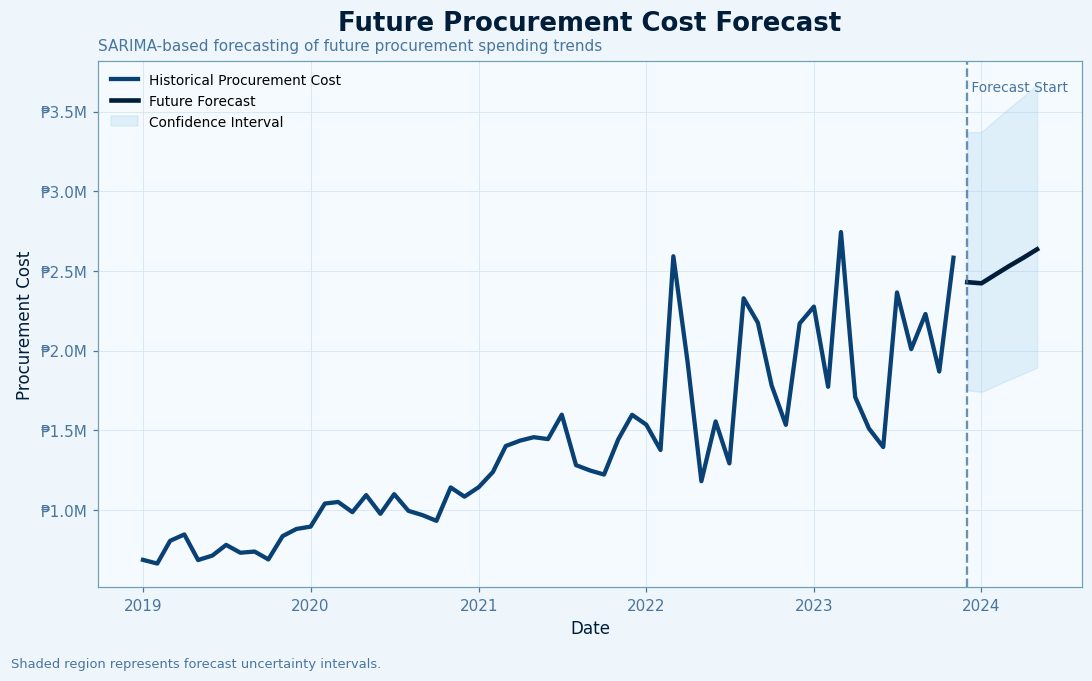

In [86]:
fig, ax = plt.subplots(figsize=(10,6))

# -- PLOT HISTORICAL DATA
ax.plot(
    ts_full.index,
    np.expm1(ts_full),
    label='Historical Procurement Cost',
    color=BLUE['dark'],
    linewidth=2.8
)

# -- PLOT FUTURE FORECAST
ax.plot(
    future_mean.index,
    np.expm1(future_mean),
    label='Future Forecast',
    color=BLUE['navy'],
    linewidth=3
)

# -- PLOT CONFIDENCE INTERVALS
ax.fill_between(
    future_ci.index,
    np.expm1(future_ci.iloc[:,0]),
    np.expm1(future_ci.iloc[:,1]),
    color=BLUE['sky'],
    alpha=0.18,
    label='Confidence Interval'
)

# -- Forecast Start Marker
forecast_start = future_mean.index[0]

ax.axvline(
    forecast_start,
    linestyle='--',
    linewidth=1.5,
    color=BLUE['mid'],
    alpha=0.8
)

ax.text(
    forecast_start,
    ax.get_ylim()[1] * 0.95,
    ' Forecast Start',
    fontsize=9,
    color=BLUE['mid']
)

ax.set_title(
    'Future Procurement Cost Forecast',
    fontsize=17,
    fontweight='bold',
    pad=20
)

ax.text(
    0,
    1.02,
    'SARIMA-based forecasting of future procurement spending trends',
    transform=ax.transAxes,
    fontsize=10,
    color=BLUE['mid']
)

ax.set_xlabel(
    'Date',
    fontsize=11
)

ax.set_ylabel(
    'Procurement Cost',
    fontsize=11
)

# -- FORMAT Y-AXIS AS CURRENCY=
from matplotlib.ticker import FuncFormatter

ax.yaxis.set_major_formatter(

    FuncFormatter(
        lambda x, p: f'₱{x/1_000_000:.1f}M'
    )
)

ax.legend(
    frameon=False,
    fontsize=9,
    loc='upper left'
)

fig.text(
    0.01,
    -0.02,
    'Shaded region represents forecast uncertainty intervals.',
    fontsize=8.5,
    color=BLUE['mid']
)

plt.tight_layout()

plt.show()

> The chart shows historical procurement costs from 2019 to 2023 and the forecasted procurement spending for future months. Historical data shows that procurement costs generally increased over time, although there were several spikes and fluctuations in spending.

> The forecast suggests that procurement costs are expected to continue increasing steadily in 2024 if current spending patterns continue. The shaded area represents forecast uncertainty, which becomes wider over time because future predictions are less certain.

> Overall, the forecast indicates growing procurement spending and highlights the need for better budgeting and financial planning.

### 6.3 Yearly Procurement Spending Overview

> Visualize long-term procurement spending growth using yearly aggregated procurement costs. This chart highlights strategic procurement
growth trends across multiple years.

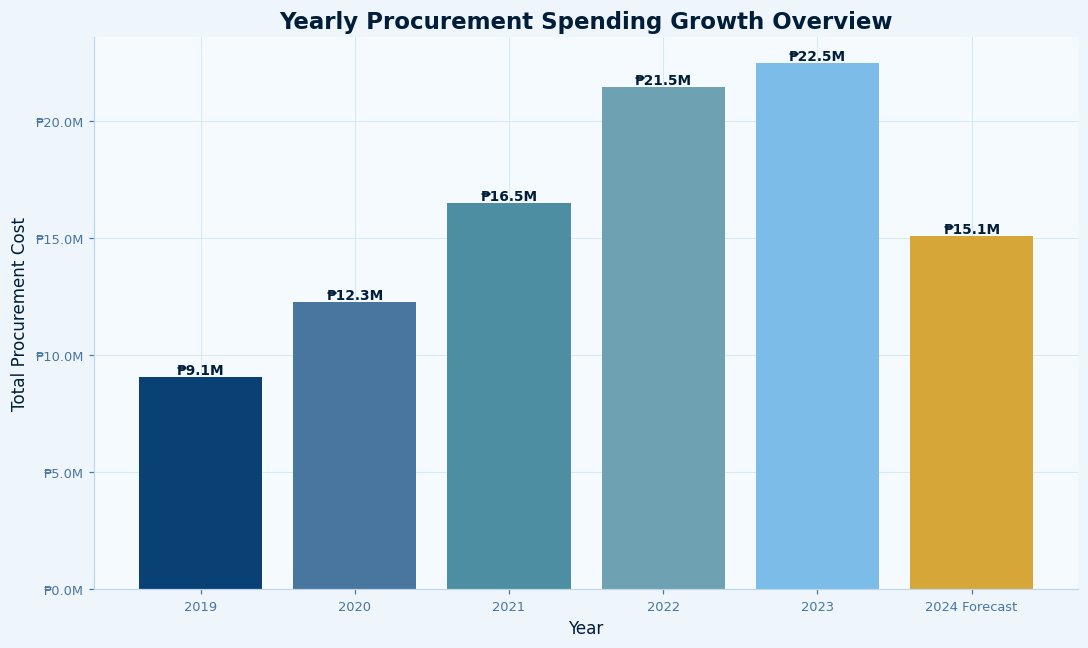

In [87]:
# -- Create Year Column

historical_yearly = pd.DataFrame({

    'Order_Date': ts_full.index,

    'Total_Cost': np.expm1(ts_full)
})

historical_yearly['Year'] = historical_yearly['Order_Date'].dt.year

# Aggregate Historical Yearly Cost
historical_yearly = historical_yearly.groupby('Year')['Total_Cost'].sum()

# -- Forecast Year Total
forecast_2024 = np.expm1(future_mean).sum()


year_labels = historical_yearly.index.astype(str).tolist()
year_values = historical_yearly.values.tolist()

# -- Add forecasted 2024
year_labels.append('2024 Forecast')
year_values.append(forecast_2024)

bar_colors = [

    BLUE['dark'],
    BLUE['mid'],
    BLUE['teal'],
    BLUE['slate'],
    BLUE['sky'],

    '#D6A638'   # Gold for forecast year
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    year_labels,
    year_values,
    color=bar_colors,
    edgecolor='none'
)


for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'₱{height/1_000_000:.1f}M',
        ha='center',
        va='bottom',
        fontsize=9,
        color=BLUE['navy'],
        fontweight='bold'
    )

ax.set_title(
    'Yearly Procurement Spending Growth Overview',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel(
    'Year',
    fontsize=11
)

ax.set_ylabel(
    'Total Procurement Cost',
    fontsize=11
)

from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, p: f'₱{x/1_000_000:.1f}M'
    )
)


clean_ax(ax)
plt.tight_layout()

plt.show()

> The chart shows the yearly growth of procurement spending from 2019 to 2023, along with the forecasted spending for 2024. Procurement costs increased steadily over the years, rising from about ₱9.1M in 2019 to ₱22.5M in 2023, showing continuous growth in procurement activities and operational spending.

> The 2024 forecast suggests that procurement spending may remain high, indicating the need for proactive budgeting and better financial planning to manage future procurement costs effectively.

### 6.2 Forecast Table

**Display future forecast in tabular form.**

In [88]:
forecast_df = pd.DataFrame({
    'Forecast': np.expm1(future_mean),
    'Lower Bound': np.expm1(future_ci.iloc[:, 0]),
    'Upper Bound': np.expm1(future_ci.iloc[:, 1])
})

print("\nFUTURE FORECAST TABLE")
print(forecast_df)


FUTURE FORECAST TABLE
                Forecast   Lower Bound   Upper Bound
2023-12-01  2.430308e+06  1.752388e+06  3.370484e+06
2024-01-01  2.423157e+06  1.741347e+06  3.371925e+06
2024-02-01  2.479224e+06  1.781743e+06  3.449740e+06
2024-03-01  2.530901e+06  1.818886e+06  3.521638e+06
2024-04-01  2.582999e+06  1.856319e+06  3.594147e+06
2024-05-01  2.636292e+06  1.894615e+06  3.668311e+06


# 📦 CONCLUSION
---

> This project successfully used SARIMA forecasting to analyze and predict future procurement costs using historical procurement data. Following the CRISP-DM framework, the project included data preparation, trend analysis, stationarity testing, model development, forecasting, and result evaluation.

> The results showed that procurement spending steadily increased from about ₱9.1 million in 2019 to ₱22.5 million in 2023, showing continuous growth in procurement activities and operational spending. The forecasting model also predicted that monthly procurement costs may continue increasing from around ₱2.43 million to nearly ₱2.98 million during 2024 if current spending patterns continue.

> The SARIMA model achieved reasonable forecasting performance with a MAE of 389,382.18, RMSE of 470,432.10, MAPE of 21.92%, and SMAPE of 19.01%. These results show that the model was able to predict procurement spending trends fairly well despite some spending fluctuations.

> Residual analysis and diagnostic tests also showed that the model captured most procurement spending patterns effectively, although some unusual spending spikes and fluctuations were still present in the forecasting errors.

> In conclusion, the study shows that predictive analytics and time-series forecasting can help organizations improve procurement planning, budgeting, and financial decision-making. By using forecasting insights, procurement personnel can better prepare for future spending changes and reduce uncertainty in procurement operations.

---


